In [2]:
pip install pandas numpy scikit-learn xgboost shap matplotlib seaborn

^C
Note: you may need to restart the kernel to use updated packages.


  Using cached shap-0.51.0-cp311-cp311-win_amd64.whl.metadata (26 kB)
Using cached shap-0.51.0-cp311-cp311-win_amd64.whl (554 kB)



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your saved data (Replace with your actual file path)
df = pd.read_csv('customer_churn1.csv')

# 2. Keep ONLY the 12 columns we agreed on to save memory
cols_to_keep = [
    'customer_id', 'tenure_months', 'subscription_type', 'contract_type', 
    'monthly_charges', 'usage_frequency', 'number_of_logins_per_month', 
    'number_of_support_tickets', 'satisfaction_score', 'payment_method', 
    'last_login_days_ago', 'churn'
]
df = df[cols_to_keep]

# 3. Convert Categorical Variables to Numbers (One-Hot Encoding)
# We drop the first column to avoid the 'dummy variable trap'
df_model = pd.get_dummies(df.drop('customer_id', axis=1), drop_first=True)

# 4. Separate Features (X) and Target (y)
X = df_model.drop('churn', axis=1)
y = df_model['churn']

print(f"Model is ready with {X.shape[1]} features!")

Model is ready with 14 features!


In [6]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Split data into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Calculate scale_pos_weight to handle imbalanced data
# This tells the model: "Hey, churners are rare, pay extra attention to them!"
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

# 3. Initialize and train the XGBoost model
model = XGBClassifier(
    n_estimators=100, 
    max_depth=4, 
    learning_rate=0.1, 
    scale_pos_weight=scale_pos_weight, # The magic parameter for imbalanced data
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# 4. Evaluate the Model
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("--- Model Performance ---")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [17:05:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Model Performance ---
ROC-AUC Score: 0.98

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      2043
           1       0.88      0.91      0.90       957

    accuracy                           0.93      3000
   macro avg       0.92      0.93      0.92      3000
weighted avg       0.93      0.93      0.93      3000



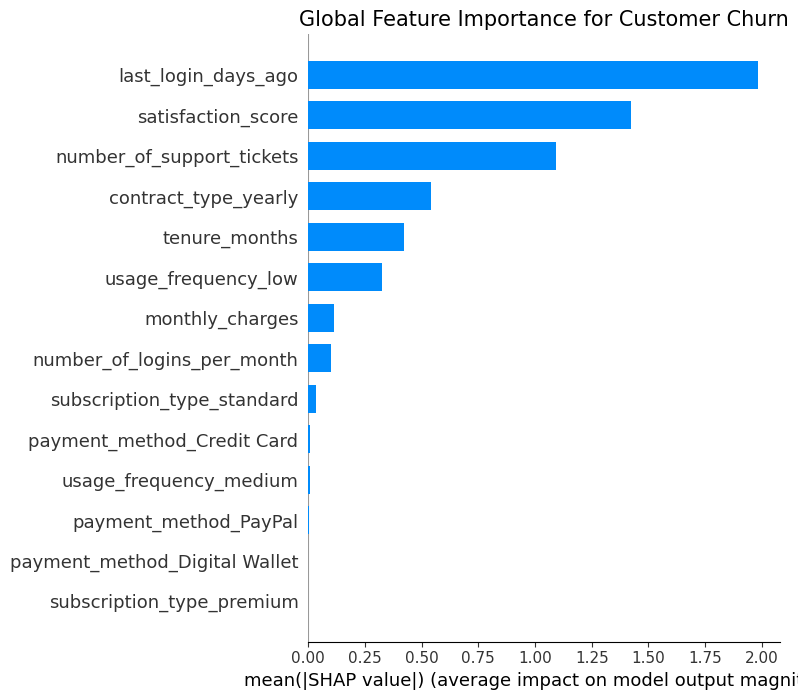

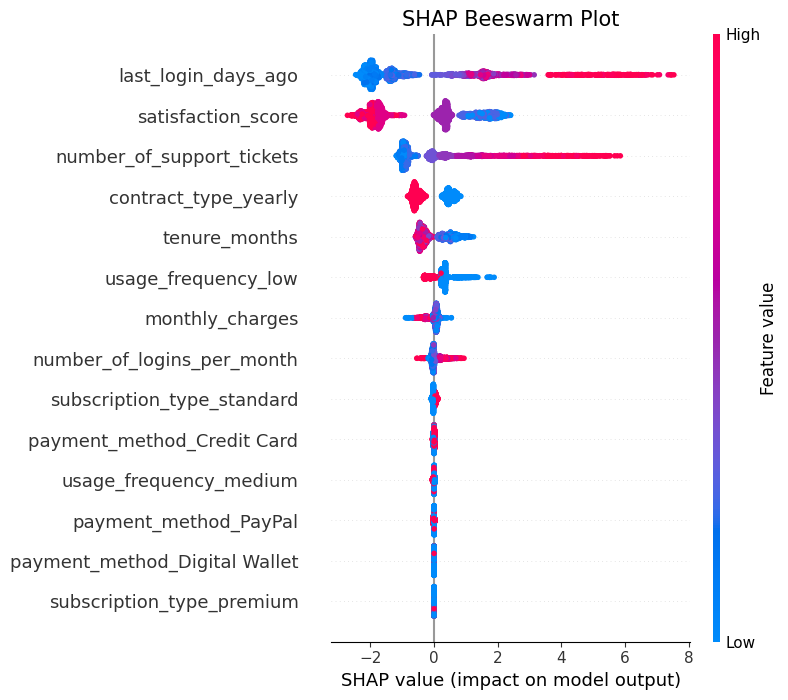

Top 10 Most Important Features
                       Feature  Mean_SHAP_Value
5          last_login_days_ago         1.980746
4           satisfaction_score         1.423503
3    number_of_support_tickets         1.090872
8         contract_type_yearly         0.543116
0                tenure_months         0.421355
9          usage_frequency_low         0.323647
1              monthly_charges         0.113747
2   number_of_logins_per_month         0.100873
7   subscription_type_standard         0.035088
11  payment_method_Credit Card         0.008988


Top Features Increasing Churn Risk
usage_frequency_low              0.248423
number_of_logins_per_month       0.039729
number_of_support_tickets        0.039706
subscription_type_premium        0.000000
payment_method_Digital Wallet    0.000000
dtype: float32


Top Features Reducing Churn Risk
satisfaction_score     -0.471632
last_login_days_ago    -0.387231
contract_type_yearly   -0.099930
tenure_months          -0.051199
monthly_char

In [9]:
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# ==========================================================
# Create folder for outputs
# ==========================================================
output_dir = "SHAP_Analysis"
os.makedirs(output_dir, exist_ok=True)

# ==========================================================
# SHAP Values
# ==========================================================
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# For binary classification
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# ==========================================================
# Global Feature Importance (Bar Plot)
# ==========================================================
plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)
plt.title("Global Feature Importance for Customer Churn", fontsize=15)
plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "01_Global_Feature_Importance.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================================
# SHAP Beeswarm Plot
# ==========================================================
plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title("SHAP Beeswarm Plot", fontsize=15)
plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "02_Beeswarm_Plot.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================================
# Feature Importance Table
# ==========================================================
importance = np.abs(shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_SHAP_Value": importance
})

importance_df = importance_df.sort_values(
    by="Mean_SHAP_Value",
    ascending=False
)

print("="*60)
print("Top 10 Most Important Features")
print("="*60)
print(importance_df.head(10))

importance_df.to_csv(
    os.path.join(output_dir,"Feature_Importance.csv"),
    index=False
)

# ==========================================================
# Positive / Negative Impact
# ==========================================================
shap_mean = pd.DataFrame(
    shap_values,
    columns=X_test.columns
).mean()

positive = shap_mean.sort_values(ascending=False).head(5)
negative = shap_mean.sort_values().head(5)

print("\n")
print("="*60)
print("Top Features Increasing Churn Risk")
print("="*60)
print(positive)

print("\n")
print("="*60)
print("Top Features Reducing Churn Risk")
print("="*60)
print(negative)

print("\n")
print("="*60)
print("Files Saved Successfully")
print("="*60)
print(f"Folder : {output_dir}")
print("- 01_Global_Feature_Importance.png")
print("- 02_Beeswarm_Plot.png")
print("- Feature_Importance.csv")

Customer Risk Segmentation

In [10]:
import pandas as pd
import numpy as np

# Predict probabilities
prob = model.predict_proba(X_test)[:, 1]

risk_df = X_test.copy()

risk_df["Churn_Probability"] = prob

risk_df["Risk_Level"] = pd.cut(
    risk_df["Churn_Probability"],
    bins=[0,0.40,0.70,1],
    labels=["Low Risk","Medium Risk","High Risk"]
)

print(risk_df[["Churn_Probability","Risk_Level"]].head())

risk_df.to_csv("Customer_Risk_Segmentation.csv",index=False)

print("\nRisk Segmentation Saved Successfully!")

       Churn_Probability Risk_Level
14239           0.110407   Low Risk
936             0.961834  High Risk
8966            0.019261   Low Risk
5961            0.999824  High Risk
12706           0.990286  High Risk

Risk Segmentation Saved Successfully!


Top Customers Most Likely to Churn

In [11]:
top_customers = risk_df.sort_values(
    by="Churn_Probability",
    ascending=False
)

top_customers.head(100).to_csv(
    "Top_100_High_Risk_Customers.csv",
    index=False
)

print(top_customers[
    ["Churn_Probability","Risk_Level"]
].head(20))

       Churn_Probability Risk_Level
2822            0.999930  High Risk
2671            0.999922  High Risk
2513            0.999915  High Risk
5225            0.999914  High Risk
4027            0.999912  High Risk
11609           0.999911  High Risk
9630            0.999910  High Risk
1798            0.999908  High Risk
4446            0.999906  High Risk
12033           0.999905  High Risk
13215           0.999904  High Risk
3378            0.999900  High Risk
5606            0.999899  High Risk
11204           0.999897  High Risk
5982            0.999895  High Risk
12600           0.999893  High Risk
864             0.999882  High Risk
1905            0.999878  High Risk
7131            0.999876  High Risk
1472            0.999868  High Risk


Revenue at Risk

In [12]:
high_risk = risk_df[
    risk_df["Risk_Level"]=="High Risk"
]

monthly_revenue_at_risk = high_risk["monthly_charges"].sum()

annual_revenue_at_risk = monthly_revenue_at_risk*12

print("="*60)
print("Monthly Revenue At Risk")
print(round(monthly_revenue_at_risk,2))

print("\nAnnual Revenue At Risk")
print(round(annual_revenue_at_risk,2))
print("="*60)

Monthly Revenue At Risk
47407.65

Annual Revenue At Risk
568891.8


Executive Business Dashboard Summary

In [13]:
total_customers = len(risk_df)

high = (risk_df["Risk_Level"]=="High Risk").sum()
medium = (risk_df["Risk_Level"]=="Medium Risk").sum()
low = (risk_df["Risk_Level"]=="Low Risk").sum()

summary = pd.DataFrame({

"Metric":[
"Total Customers",
"High Risk",
"Medium Risk",
"Low Risk",
"Monthly Revenue At Risk",
"Annual Revenue At Risk"
],

"Value":[
total_customers,
high,
medium,
low,
round(monthly_revenue_at_risk,2),
round(annual_revenue_at_risk,2)
]

})

print(summary)

summary.to_csv(
    "Business_Summary.csv",
    index=False
)

                    Metric      Value
0          Total Customers    3000.00
1                High Risk     914.00
2              Medium Risk     110.00
3                 Low Risk    1976.00
4  Monthly Revenue At Risk   47407.65
5   Annual Revenue At Risk  568891.80


Feature Importance (Model-Based)

In [14]:
importance = pd.DataFrame({

"Feature":X_test.columns,
"Importance":model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.to_csv(
    "Model_Feature_Importance.csv",
    index=False
)

print(importance.head(15))

                          Feature  Importance
5             last_login_days_ago    0.338646
4              satisfaction_score    0.216547
3       number_of_support_tickets    0.177111
9             usage_frequency_low    0.101456
8            contract_type_yearly    0.068107
0                   tenure_months    0.041127
7      subscription_type_standard    0.012780
13          payment_method_PayPal    0.010823
1                 monthly_charges    0.009299
2      number_of_logins_per_month    0.009228
10         usage_frequency_medium    0.008515
11     payment_method_Credit Card    0.006362
6       subscription_type_premium    0.000000
12  payment_method_Digital Wallet    0.000000
